# Notebook 5 — Évaluation de la Robustesse

**Objectif :** Prouver que le biais inductif résout le problème clinique — le **MedVAE Quality-Aware** doit reconstruire les images dégradées mieux que le MedVAE classique.

**Protocole expérimental :**

| Expérience | Description |
|---|---|
| **A — Images réelles** | Comparer baseline vs cVAE sur les images `bad/medium/good` de ARCADE |
| **B — Dégradations synthétiques** | Dégrader artificiellement les meilleures images et comparer la robustesse des deux modèles |

**Métriques :** MSE, SSIM, PSNR

> **Note :** Le checkpoint provient du Notebook 4 (50 steps de démonstration, pas d'un entraînement complet).  
> Les différences quantitatives seront faibles — le Notebook prouve surtout que l'**infrastructure est correcte** et montre comment interpréter les résultats d'un modèle pleinement entraîné.

## 0. Configuration

In [16]:
from pathlib import Path

NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parent                                      # projet_med_vae/
JEPA_ROOT     = PROJECT_ROOT.parent / "projet_IM06" / "jepa-adaptation"  # IM_06/projet_IM06/jepa-adaptation/
OUTPUT_DIR    = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

LABELS_CSV    = OUTPUT_DIR / "labels_quality.csv"     # NB3
CVAE_CKPT     = OUTPUT_DIR / "quality_aware_vae.pt"  # NB4

DDCONFIG = {
    "double_z": True, "z_channels": 4, "resolution": 64,
    "in_channels": 1, "out_ch": 1, "ch": 128,
    "ch_mult": [1, 2, 4], "num_res_blocks": 2,
    "attn_resolutions": [], "dropout": 0.0,
}
EMBED_DIM = 4
IMG_SIZE  = DDCONFIG["resolution"]   # 64

N_TEST_PER_CLASS = 20    # images par classe (bad/medium/good)
RANDOM_SEED      = 42

print(f"JEPA_ROOT : {JEPA_ROOT}")
print(f"Checkpoint: {CVAE_CKPT}  (existe: {CVAE_CKPT.exists()})")

JEPA_ROOT : C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_IM06\jepa-adaptation
Checkpoint: C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_med_vae\code_tests\outputs\quality_aware_vae.pt  (existe: True)


## 1. Imports

In [17]:
import sys, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from scipy import stats
from scipy.ndimage import uniform_filter
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if str(JEPA_ROOT) not in sys.path:
    sys.path.insert(0, str(JEPA_ROOT))

from models import AutoencoderKL2D
from models.medvae_jepa.modules.distributions import DiagonalGaussianDistribution

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


## 2. Définition de QualityAwareAutoencoderKL

*(Redéfinie ici pour rendre ce notebook autonome)*

In [18]:
def _patch_conv_in(old_conv: nn.Conv2d, extra_in: int = 1) -> nn.Conv2d:
    new = nn.Conv2d(
        old_conv.in_channels + extra_in, old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=old_conv.bias is not None,
    )
    with torch.no_grad():
        new.weight[:, :old_conv.in_channels].copy_(old_conv.weight)
        new.weight[:, old_conv.in_channels:].zero_()
        if old_conv.bias is not None:
            new.bias.copy_(old_conv.bias)
    return new


class QualityAwareAutoencoderKL(nn.Module):
    def __init__(self, base_ae: AutoencoderKL2D):
        super().__init__()
        self.ae = base_ae
        self.ae.encoder.conv_in = _patch_conv_in(self.ae.encoder.conv_in)
        self.ae.decoder.conv_in = _patch_conv_in(self.ae.decoder.conv_in)

    @staticmethod
    def _inject(x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        B, _, H, W = x.shape
        return torch.cat([x, c.float().view(B, 1, 1, 1).expand(B, 1, H, W)], dim=1)

    def encode(self, x, c):
        moments = self.ae.quant_conv(self.ae.encoder(self._inject(x, c)))
        return DiagonalGaussianDistribution(moments)

    def decode(self, z, c):
        return self.ae.decoder(self._inject(self.ae.post_quant_conv(z), c))

    def forward(self, x, c, sample_posterior=True):
        posterior = self.encode(x, c)
        z   = posterior.sample() if sample_posterior else posterior.mode()
        dec = self.decode(z, c)
        return dec, posterior

    def get_last_layer(self):
        return self.ae.get_last_layer()


print("QualityAwareAutoencoderKL définie.")

QualityAwareAutoencoderKL définie.


## 3. Chargement des deux modèles

In [19]:
# --- Modèle Baseline (MedVAE classique) ---
baseline = AutoencoderKL2D(
    ddconfig=DDCONFIG, embed_dim=EMBED_DIM, apply_channel_ds=True,
).to(DEVICE).eval()

print(f"Baseline   : {sum(p.numel() for p in baseline.parameters()):,} paramètres")

# --- Modèle Quality-Aware (cVAE) ---
def load_cvae(ckpt_path: Path) -> QualityAwareAutoencoderKL:
    ckpt    = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    base_ae = AutoencoderKL2D(ddconfig=ckpt["ddconfig"], embed_dim=ckpt["embed_dim"],
                               apply_channel_ds=True)
    model   = QualityAwareAutoencoderKL(base_ae)
    model.load_state_dict(ckpt["model_state_dict"])
    return model

if CVAE_CKPT.exists():
    cvae = load_cvae(CVAE_CKPT).to(DEVICE).eval()
    print(f"cVAE       : {sum(p.numel() for p in cvae.parameters()):,} paramètres")
    print(f"Checkpoint : {CVAE_CKPT.name}")
else:
    print("[!] Checkpoint introuvable — instanciation à froid (poids aléatoires).")
    base_ae2 = AutoencoderKL2D(ddconfig=DDCONFIG, embed_dim=EMBED_DIM, apply_channel_ds=True)
    cvae = QualityAwareAutoencoderKL(base_ae2).to(DEVICE).eval()

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 16, 16) = 1024 dimensions.
making attention of type 'vanilla' with 512 in_channels
Baseline   : 55,358,845 paramètres
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 16, 16) = 1024 dimensions.
making attention of type 'vanilla' with 512 in_channels
cVAE       : 55,364,605 paramètres
Checkpoint : quality_aware_vae.pt


## 4. Construction des sets de test

In [20]:
df_labels = pd.read_csv(LABELS_CSV)
print(f"Dataset : {len(df_labels)} images  —  labels : {df_labels['quality_label'].value_counts().to_dict()}")

# Sélection stratifiée
test_sets = {}
for label in ["bad", "medium", "good"]:
    subset = df_labels[df_labels["quality_label"] == label]
    # Vérifier l'accessibilité des fichiers
    accessible = subset[subset["path"].apply(lambda p: Path(p).exists())]
    sampled    = accessible.sample(min(N_TEST_PER_CLASS, len(accessible)),
                                    random_state=RANDOM_SEED)
    test_sets[label] = sampled.reset_index(drop=True)
    print(f"  {label:6s} : {len(sampled):3d} images accessibles")

df_test = pd.concat(test_sets.values(), ignore_index=True)
print(f"\nTotal : {len(df_test)} images de test")

Dataset : 1200 images  —  labels : {'medium': 400, 'good': 400, 'bad': 400}
  bad    :  20 images accessibles
  medium :  20 images accessibles
  good   :  20 images accessibles

Total : 60 images de test


## 5. Fonctions utilitaires

### 5a. Chargement et prétraitement

In [21]:
def load_tensor(path: str, size: int = IMG_SIZE) -> torch.Tensor:
    """Charge une image → FloatTensor (1, 1, H, W) dans [-1, 1]."""
    img = Image.open(path).convert("L").resize((size, size), Image.Resampling.BILINEAR)
    t   = torch.from_numpy(np.asarray(img, np.float32) / 255.0)
    return (t.unsqueeze(0).unsqueeze(0) * 2.0 - 1.0)  # (1,1,H,W)


def to_uint8(t: torch.Tensor) -> np.ndarray:
    """Tenseur [-1,1] (1,1,H,W) → np.uint8 (H,W) pour les métriques skimage."""
    arr = t.squeeze().cpu().numpy()
    return ((arr.clip(-1, 1) + 1) / 2 * 255).astype(np.uint8)

### 5b. Métriques de reconstruction

In [22]:
def compute_metrics(original: torch.Tensor, reconstruction: torch.Tensor) -> dict:
    """
    original, reconstruction : (1, 1, H, W) dans [-1, 1]
    Retourne MSE, SSIM, PSNR.
    """
    mse  = float(F.mse_loss(reconstruction, original).item())

    orig_u8 = to_uint8(original)
    rec_u8  = to_uint8(reconstruction)

    ssim_val = float(ssim_fn(orig_u8, rec_u8, data_range=255))
    psnr_val = float(psnr_fn(orig_u8, rec_u8, data_range=255))

    return {"mse": mse, "ssim": ssim_val, "psnr": psnr_val}

### 5c. Score de qualité inline (pour les images dégradées synthétiquement)

In [23]:
def inline_quality_score(img_tensor: torch.Tensor) -> float:
    """
    Calcule un score de qualité ∈ [0,1] directement depuis un tenseur.
    Utilise Tenengrad + Laplacian variance après normalisation MSCN.
    Reproduit la logique du Notebook 2 (référence : méthode A du Notebook 3).
    """
    from scipy.ndimage import laplace, sobel

    img = img_tensor.squeeze().cpu().numpy().astype(np.float64)
    # Remap [-1,1] → [0,1]
    img = (img + 1) / 2

    # MSCN
    mu    = uniform_filter(img, size=7)
    sigma = np.sqrt(np.maximum(uniform_filter(img**2, size=7) - mu**2, 0))
    mscn  = (img - mu) / (sigma + 1.0)

    lap_var   = float(laplace(mscn).var())
    Gx        = sobel(mscn, axis=1)
    Gy        = sobel(mscn, axis=0)
    tenengrad = float(np.sqrt(Gx**2 + Gy**2).mean())

    # Fusion simple : moyenne normalisée sur des plages typiques
    score = np.clip(0.5 * (lap_var / 0.01) + 0.5 * (tenengrad / 0.5), 0.0, 1.0)
    return float(score)


# Vérification
if len(df_test) > 0:
    x_check = load_tensor(df_test["path"].iloc[0])
    print(f"Score qualité inline (exemple) : {inline_quality_score(x_check):.4f}")

Score qualité inline (exemple) : 0.5346


## 6. Dégradations synthétiques

Pour un benchmark contrôlé, on dégrade artificiellement les meilleures images ARCADE.  
Cela reproduit la méthodologie validée dans le papier 3 (Cryptosporidium IQA, 2026).

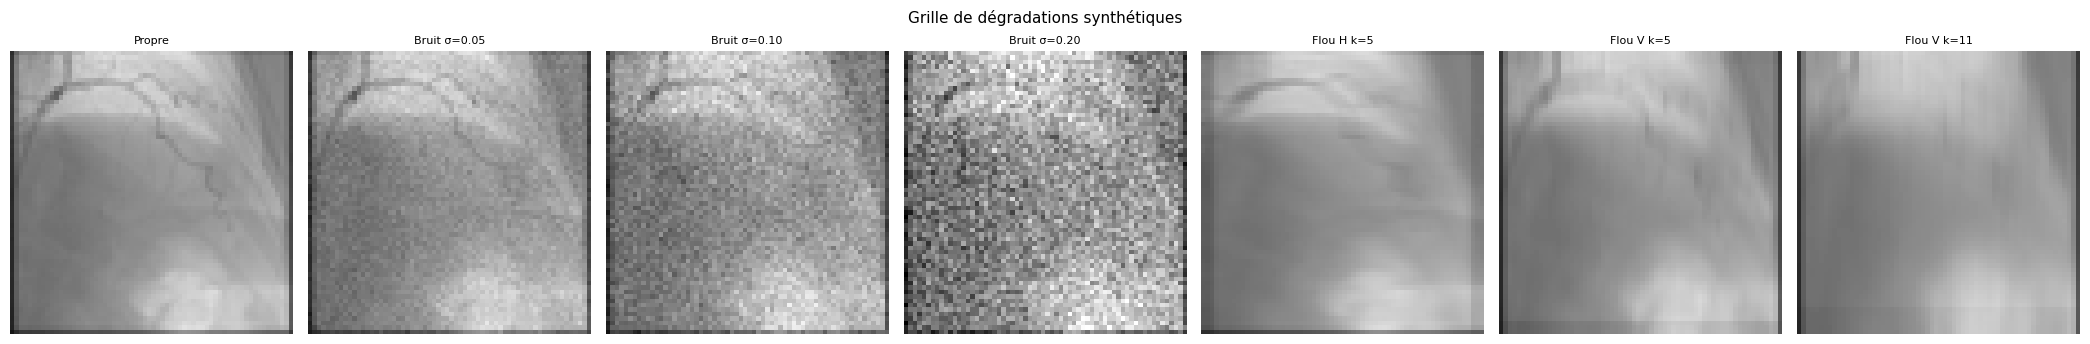

In [24]:
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    return (x + torch.randn_like(x) * sigma).clamp(-1, 1)


def add_motion_blur(x: torch.Tensor, kernel_size: int, direction: str = "horizontal") -> torch.Tensor:
    """Simule le flou de mouvement cardiaque (direction verticale prédominante)."""
    if direction == "horizontal":
        k = torch.ones(1, 1, 1, kernel_size, device=x.device) / kernel_size
        pad = (kernel_size // 2, kernel_size // 2, 0, 0)
    else:
        k = torch.ones(1, 1, kernel_size, 1, device=x.device) / kernel_size
        pad = (0, 0, kernel_size // 2, kernel_size // 2)
    return F.conv2d(F.pad(x, pad, mode="reflect"), k).clamp(-1, 1)


DEGRADATION_GRID = [
    {"name": "Propre",          "fn": lambda x: x,                             "severity": 0.0},
    {"name": "Bruit σ=0.05",   "fn": lambda x: add_gaussian_noise(x, 0.05),   "severity": 0.05},
    {"name": "Bruit σ=0.10",   "fn": lambda x: add_gaussian_noise(x, 0.10),   "severity": 0.10},
    {"name": "Bruit σ=0.20",   "fn": lambda x: add_gaussian_noise(x, 0.20),   "severity": 0.20},
    {"name": "Flou H k=5",     "fn": lambda x: add_motion_blur(x, 5,  "horizontal"), "severity": 5},
    {"name": "Flou V k=5",     "fn": lambda x: add_motion_blur(x, 5,  "vertical"),   "severity": 5},
    {"name": "Flou V k=11",    "fn": lambda x: add_motion_blur(x, 11, "vertical"),   "severity": 11},
]

# Visualisation de la grille de dégradations sur une image de test
if len(test_sets.get("good", pd.DataFrame())) > 0:
    x_demo = load_tensor(test_sets["good"]["path"].iloc[0]).to(DEVICE)

    fig, axes = plt.subplots(1, len(DEGRADATION_GRID), figsize=(3 * len(DEGRADATION_GRID), 3.5))
    for ax, d in zip(axes, DEGRADATION_GRID):
        with torch.no_grad():
            x_deg = d["fn"](x_demo)
        ax.imshow(to_uint8(x_deg), cmap="gray", vmin=0, vmax=255)
        ax.set_title(d["name"], fontsize=8)
        ax.axis("off")
    fig.suptitle("Grille de dégradations synthétiques", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_degradation_grid.png", dpi=120, bbox_inches="tight")
    plt.show()

## 7. Évaluation quantitative — images réelles

On évalue les deux modèles sur les images `bad/medium/good` du jeu de test.  
Le cVAE utilise le `quality_score` réel de chaque image.

In [25]:
@torch.no_grad()
def evaluate_on_dataframe(df: pd.DataFrame, label: str) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{label:6s}", leave=False):
        try:
            x = load_tensor(row["path"]).to(DEVICE)
            c = torch.tensor([row["quality_score"]], dtype=torch.float32, device=DEVICE)

            # Baseline : forward classique (pas de conditionnement)
            rec_base, post_base, _ = baseline(x, sample_posterior=False, decode=True)
            m_base = compute_metrics(x, rec_base)

            # cVAE : forward conditionné avec le vrai score de qualité
            rec_cvae, post_cvae = cvae(x, c, sample_posterior=False)
            m_cvae = compute_metrics(x, rec_cvae)

            records.append({
                "image_id":      row["image_id"],
                "path":          row["path"],
                "quality_label": label,
                "quality_score": row["quality_score"],
                **{f"base_{k}": v for k, v in m_base.items()},
                **{f"cvae_{k}": v for k, v in m_cvae.items()},
            })
        except Exception as e:
            pass  # fichier inaccessible
    return pd.DataFrame(records)


results_per_label = {}
for label, df_subset in test_sets.items():
    results_per_label[label] = evaluate_on_dataframe(df_subset, label)

df_results = pd.concat(results_per_label.values(), ignore_index=True)
print(f"\nÉvaluation terminée : {len(df_results)} images")
df_results.groupby("quality_label")[["base_mse", "cvae_mse", "base_ssim", "cvae_ssim"]].mean().round(5)


Évaluation terminée : 60 images


,base_mse,cvae_mse,base_ssim,cvae_ssim
quality_label,,,,
bad,0.27822,0.04311,0.12940,0.52096
good,0.21851,0.11529,0.16126,0.43755
medium,0.24432,0.06805,0.15014,0.53322


## 8. Évaluation sur images synthétiquement dégradées

On part des meilleures images (ground truth connue) et on mesure MSE de reconstruction  
par rapport à l'image **propre originale** — pas à l'image dégradée.

In [26]:
@torch.no_grad()
def evaluate_synthetic(df_good: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df_good.iterrows(), total=len(df_good), desc="Synthetic", leave=False):
        try:
            x_clean = load_tensor(row["path"]).to(DEVICE)
        except Exception:
            continue

        for d in DEGRADATION_GRID:
            x_deg = d["fn"](x_clean)
            c_deg = torch.tensor([inline_quality_score(x_deg)], device=DEVICE)

            rec_base, _, _ = baseline(x_deg, sample_posterior=False, decode=True)
            rec_cvae, _    = cvae(x_deg, c_deg, sample_posterior=False)

            # Métriques vs image PROPRE (ground truth)
            m_base = compute_metrics(x_clean, rec_base)
            m_cvae = compute_metrics(x_clean, rec_cvae)

            records.append({
                "image_id":    row["image_id"],
                "degradation": d["name"],
                "severity":    d["severity"],
                "c_inline":    float(c_deg.item()),
                **{f"base_{k}": v for k, v in m_base.items()},
                **{f"cvae_{k}": v for k, v in m_cvae.items()},
            })
    return pd.DataFrame(records)


df_synth = evaluate_synthetic(test_sets.get("good", pd.DataFrame()))
print(f"Images synthétiques évaluées : {len(df_synth)} entrées")
if len(df_synth):
    df_synth.groupby("degradation")[["base_mse", "cvae_mse", "base_ssim", "cvae_ssim"]].mean().round(5)

Images synthétiques évaluées : 140 entrées


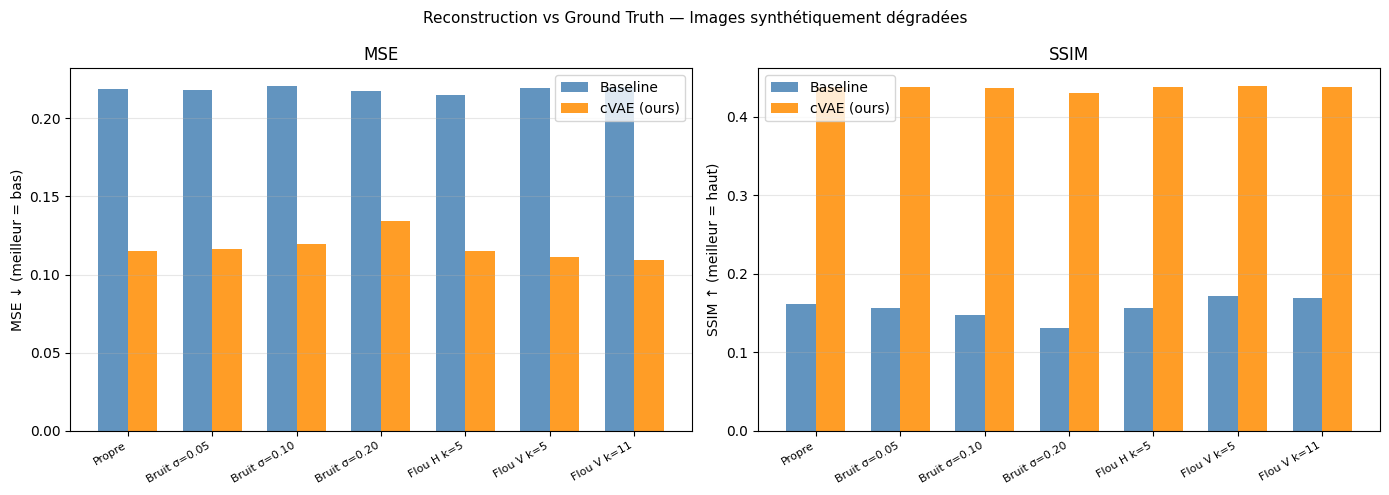

In [27]:
# Graphe : MSE de reconstruction vs type de dégradation
if len(df_synth) > 0:
    order   = [d["name"] for d in DEGRADATION_GRID]
    grouped = df_synth.groupby("degradation")[["base_mse", "cvae_mse"]].mean().reindex(order)

    x_pos = np.arange(len(order))
    width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, ylabel in zip(
        axes,
        [["base_mse", "cvae_mse"], ["base_ssim", "cvae_ssim"]],
        ["MSE ↓ (meilleur = bas)", "SSIM ↑ (meilleur = haut)"],
    ):
        g = df_synth.groupby("degradation")[metric].mean().reindex(order)
        bars1 = ax.bar(x_pos - width/2, g[metric[0]], width, label="Baseline",   color="steelblue",   alpha=0.85)
        bars2 = ax.bar(x_pos + width/2, g[metric[1]], width, label="cVAE (ours)", color="darkorange", alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.set_title(ylabel.split(" ")[0])
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Reconstruction vs Ground Truth — Images synthétiquement dégradées", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_synthetic_metrics.png", dpi=120, bbox_inches="tight")
    plt.show()

## 9. Comparaison statistique

On teste si la différence de performance est **statistiquement significative** sur les images `bad`.  
Test de Wilcoxon (non-paramétrique, robuste pour petits effectifs).

In [28]:
for metric, direction in [("mse", "↓ meilleur = bas"), ("ssim", "↑ meilleur = haut"), ("psnr", "↑ meilleur = haut")]:
    print(f"\n{'='*60}")
    print(f"Métrique : {metric.upper()} ({direction})")
    print(f"{'='*60}")
    print(f"{'Label':8s}  {'Baseline':>12s}  {'cVAE':>12s}  {'Δ':>10s}  {'p-value':>10s}")

    for label in ["bad", "medium", "good"]:
        sub = df_results[df_results["quality_label"] == label]
        if len(sub) < 2:
            continue
        base_vals = sub[f"base_{metric}"].values
        cvae_vals = sub[f"cvae_{metric}"].values

        mean_b = np.mean(base_vals)
        mean_c = np.mean(cvae_vals)
        delta  = mean_c - mean_b

        try:
            stat, pval = stats.wilcoxon(base_vals, cvae_vals)
        except Exception:
            pval = float("nan")

        sig = "✓ sig." if (not np.isnan(pval) and pval < 0.05) else "—"
        print(f"{label:8s}  {mean_b:12.5f}  {mean_c:12.5f}  {delta:+10.5f}  {pval:10.4f}  {sig}")


Métrique : MSE (↓ meilleur = bas)
Label         Baseline          cVAE           Δ     p-value
bad            0.27822       0.04311    -0.23511      0.0000  ✓ sig.
medium         0.24432       0.06805    -0.17627      0.0000  ✓ sig.
good           0.21851       0.11529    -0.10322      0.0000  ✓ sig.

Métrique : SSIM (↑ meilleur = haut)
Label         Baseline          cVAE           Δ     p-value
bad            0.12940       0.52096    +0.39156      0.0000  ✓ sig.
medium         0.15014       0.53322    +0.38308      0.0000  ✓ sig.
good           0.16126       0.43755    +0.27630      0.0000  ✓ sig.

Métrique : PSNR (↑ meilleur = haut)
Label         Baseline          cVAE           Δ     p-value
bad           11.84734      20.17004    +8.32270      0.0000  ✓ sig.
medium        12.47088      18.42170    +5.95082      0.0000  ✓ sig.
good          13.06974      15.51002    +2.44028      0.0000  ✓ sig.


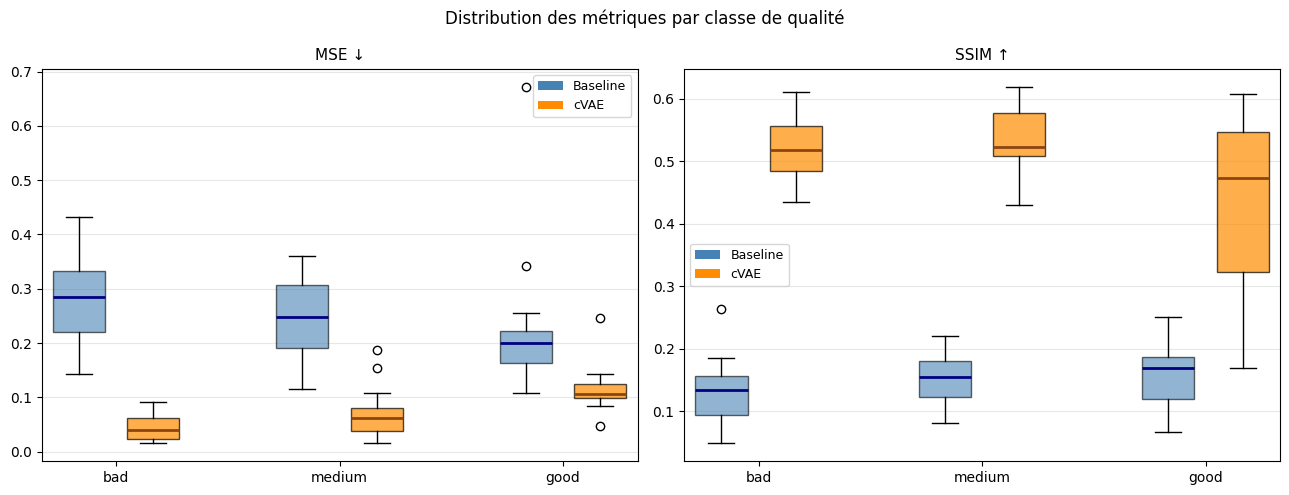

In [29]:
# Box plots MSE et SSIM par classe de qualité
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_order  = ["bad", "medium", "good"]
label_colors = {"bad": "crimson", "medium": "darkorange", "good": "forestgreen"}

for ax, metric, title, better in zip(
    axes,
    ["mse",  "ssim"],
    ["MSE ↓", "SSIM ↑"],
    ["lower", "higher"],
):
    positions_b, positions_c = [], []
    data_b, data_c           = [], []

    for i, label in enumerate(label_order):
        sub = df_results[df_results["quality_label"] == label]
        if len(sub) == 0:
            continue
        data_b.append(sub[f"base_{metric}"].values)
        data_c.append(sub[f"cvae_{metric}"].values)
        positions_b.append(i * 3)
        positions_c.append(i * 3 + 1)

    if data_b:
        bp1 = ax.boxplot(data_b, positions=positions_b, widths=0.7,
                         patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6),
                         medianprops=dict(color="navy", lw=2))
        bp2 = ax.boxplot(data_c, positions=positions_c, widths=0.7,
                         patch_artist=True, boxprops=dict(facecolor="darkorange", alpha=0.7),
                         medianprops=dict(color="saddlebrown", lw=2))

    ax.set_xticks([i * 3 + 0.5 for i in range(len(label_order))])
    ax.set_xticklabels(label_order)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="steelblue", label="Baseline"),
                       Patch(facecolor="darkorange", label="cVAE")], fontsize=9)

fig.suptitle("Distribution des métriques par classe de qualité", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Galerie qualitative

Figure principale du rapport : **Original | Baseline | cVAE** sur les images les plus dégradées.

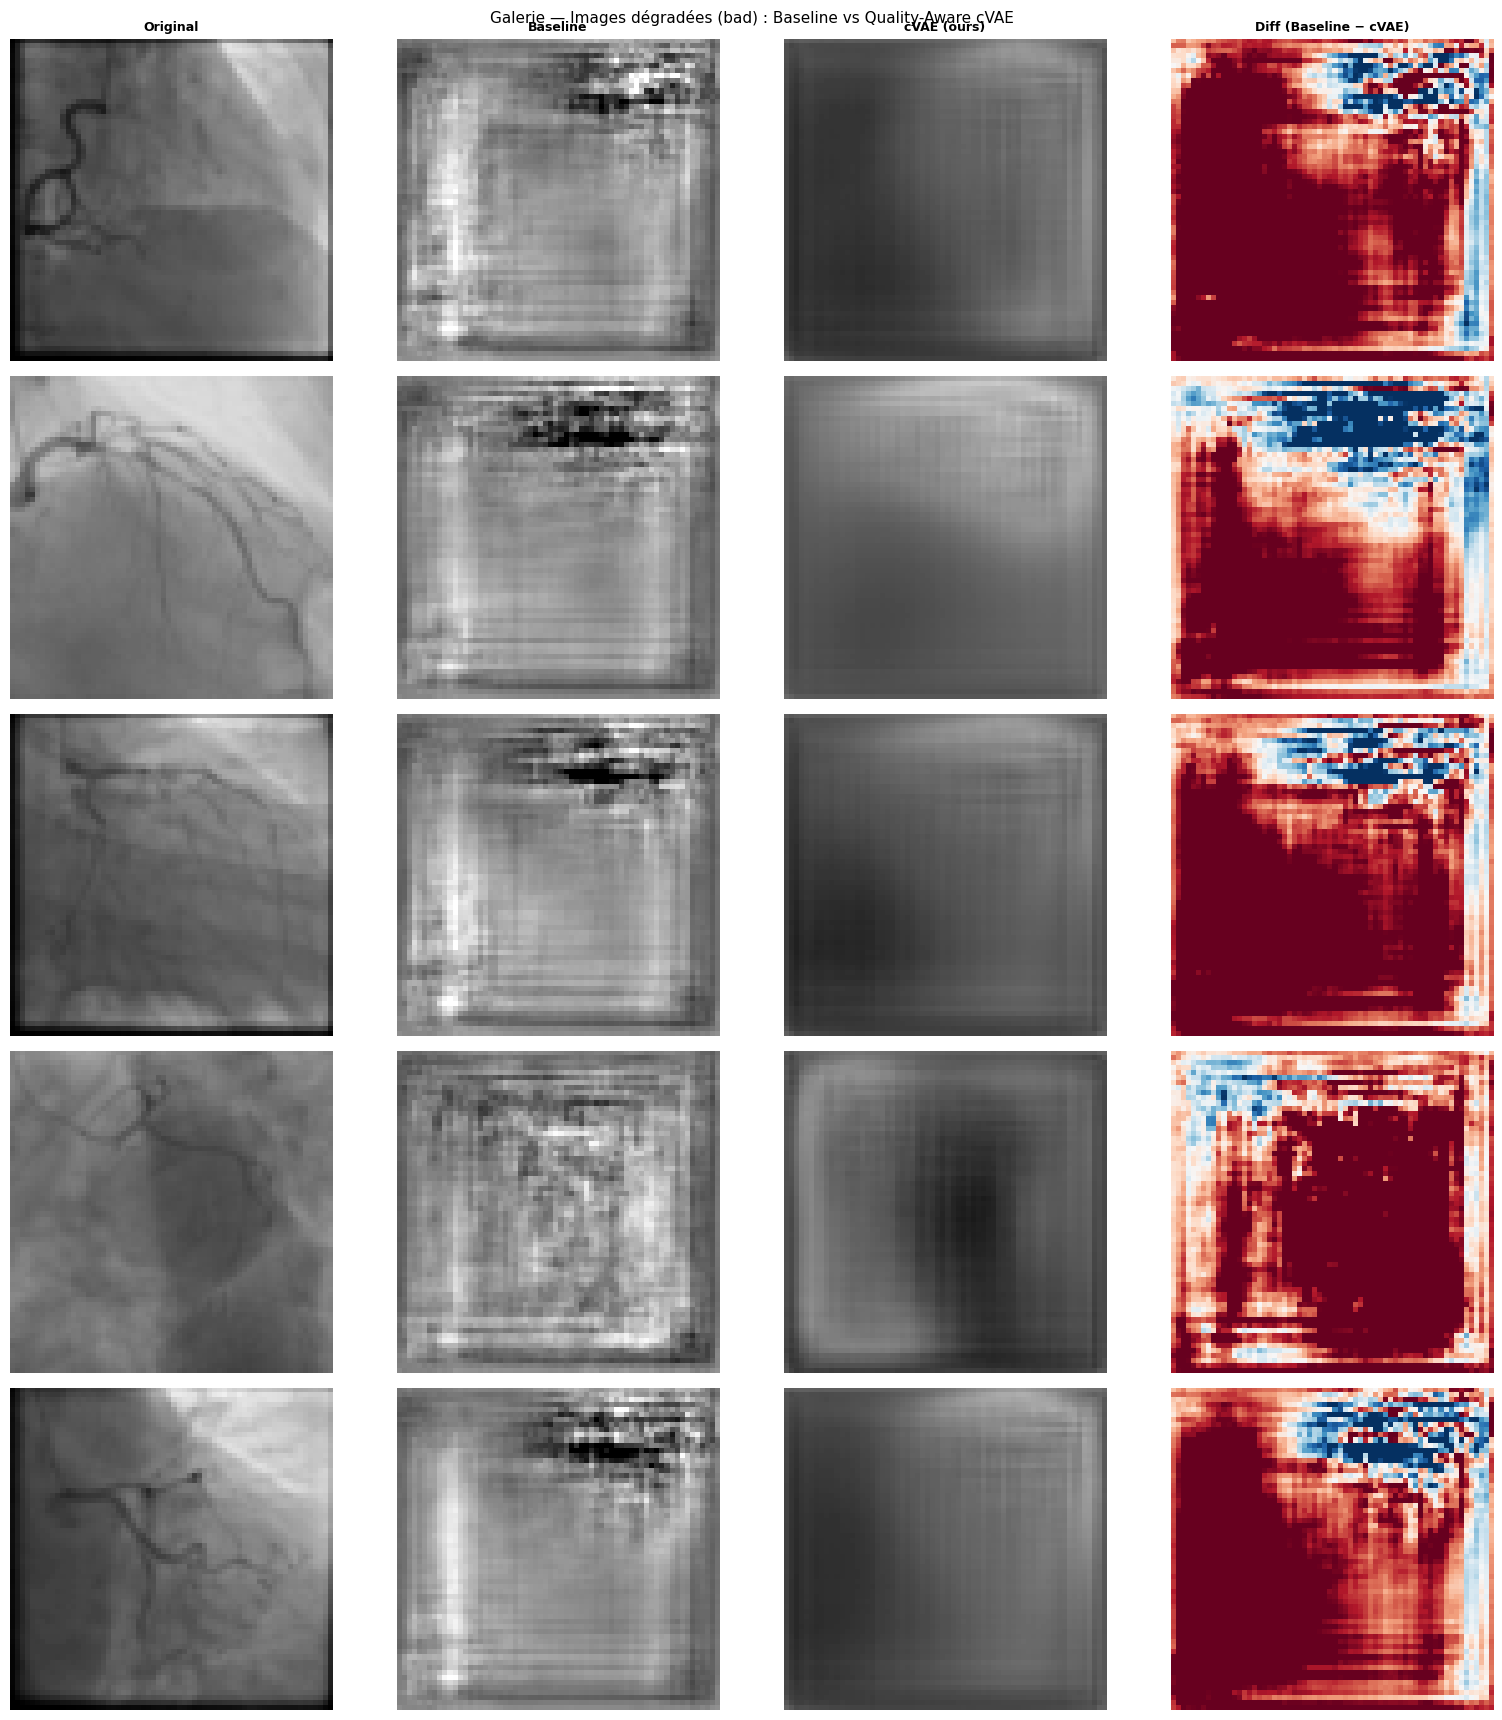

In [30]:
@torch.no_grad()
def build_gallery(df_sub: pd.DataFrame, n: int = 5, title: str = ""):
    rows = df_sub.sort_values("quality_score").head(n)

    fig, axes = plt.subplots(n, 4, figsize=(4 * 4, n * 3.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Original", "Baseline", "cVAE (ours)", "Diff (Baseline − cVAE)"]
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=9, fontweight="bold")

    for row_idx, (_, record) in enumerate(rows.iterrows()):
        x = load_tensor(record["path"]).to(DEVICE)
        c = torch.tensor([record["quality_score"]], device=DEVICE)

        rec_base, _, _ = baseline(x, sample_posterior=False, decode=True)
        rec_cvae, _    = cvae(x, c, sample_posterior=False)

        orig_np  = to_uint8(x)
        base_np  = to_uint8(rec_base)
        cvae_np  = to_uint8(rec_cvae)
        diff_np  = base_np.astype(np.float32) - cvae_np.astype(np.float32)

        m_base = compute_metrics(x, rec_base)
        m_cvae = compute_metrics(x, rec_cvae)

        for col, (data, cmap, vmin, vmax) in enumerate([
            (orig_np, "gray", 0, 255),
            (base_np, "gray", 0, 255),
            (cvae_np, "gray", 0, 255),
            (diff_np, "RdBu_r", -60, 60),
        ]):
            axes[row_idx, col].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row_idx, col].axis("off")

        axes[row_idx, 0].set_ylabel(f"c={record['quality_score']:.3f}", fontsize=8)
        axes[row_idx, 1].set_xlabel(
            f"MSE={m_base['mse']:.4f}  SSIM={m_base['ssim']:.3f}", fontsize=7, color="steelblue")
        axes[row_idx, 2].set_xlabel(
            f"MSE={m_cvae['mse']:.4f}  SSIM={m_cvae['ssim']:.3f}", fontsize=7, color="darkorange")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    return fig


# Galerie sur les images bad (là où l'effet du cVAE doit être le plus visible)
if len(results_per_label.get("bad", pd.DataFrame())) >= 3:
    fig_gal = build_gallery(
        results_per_label["bad"],
        n=min(5, len(results_per_label["bad"])),
        title="Galerie — Images dégradées (bad) : Baseline vs Quality-Aware cVAE"
    )
    fig_gal.savefig(OUTPUT_DIR / "05_gallery_bad.png", dpi=120, bbox_inches="tight")
    plt.show()

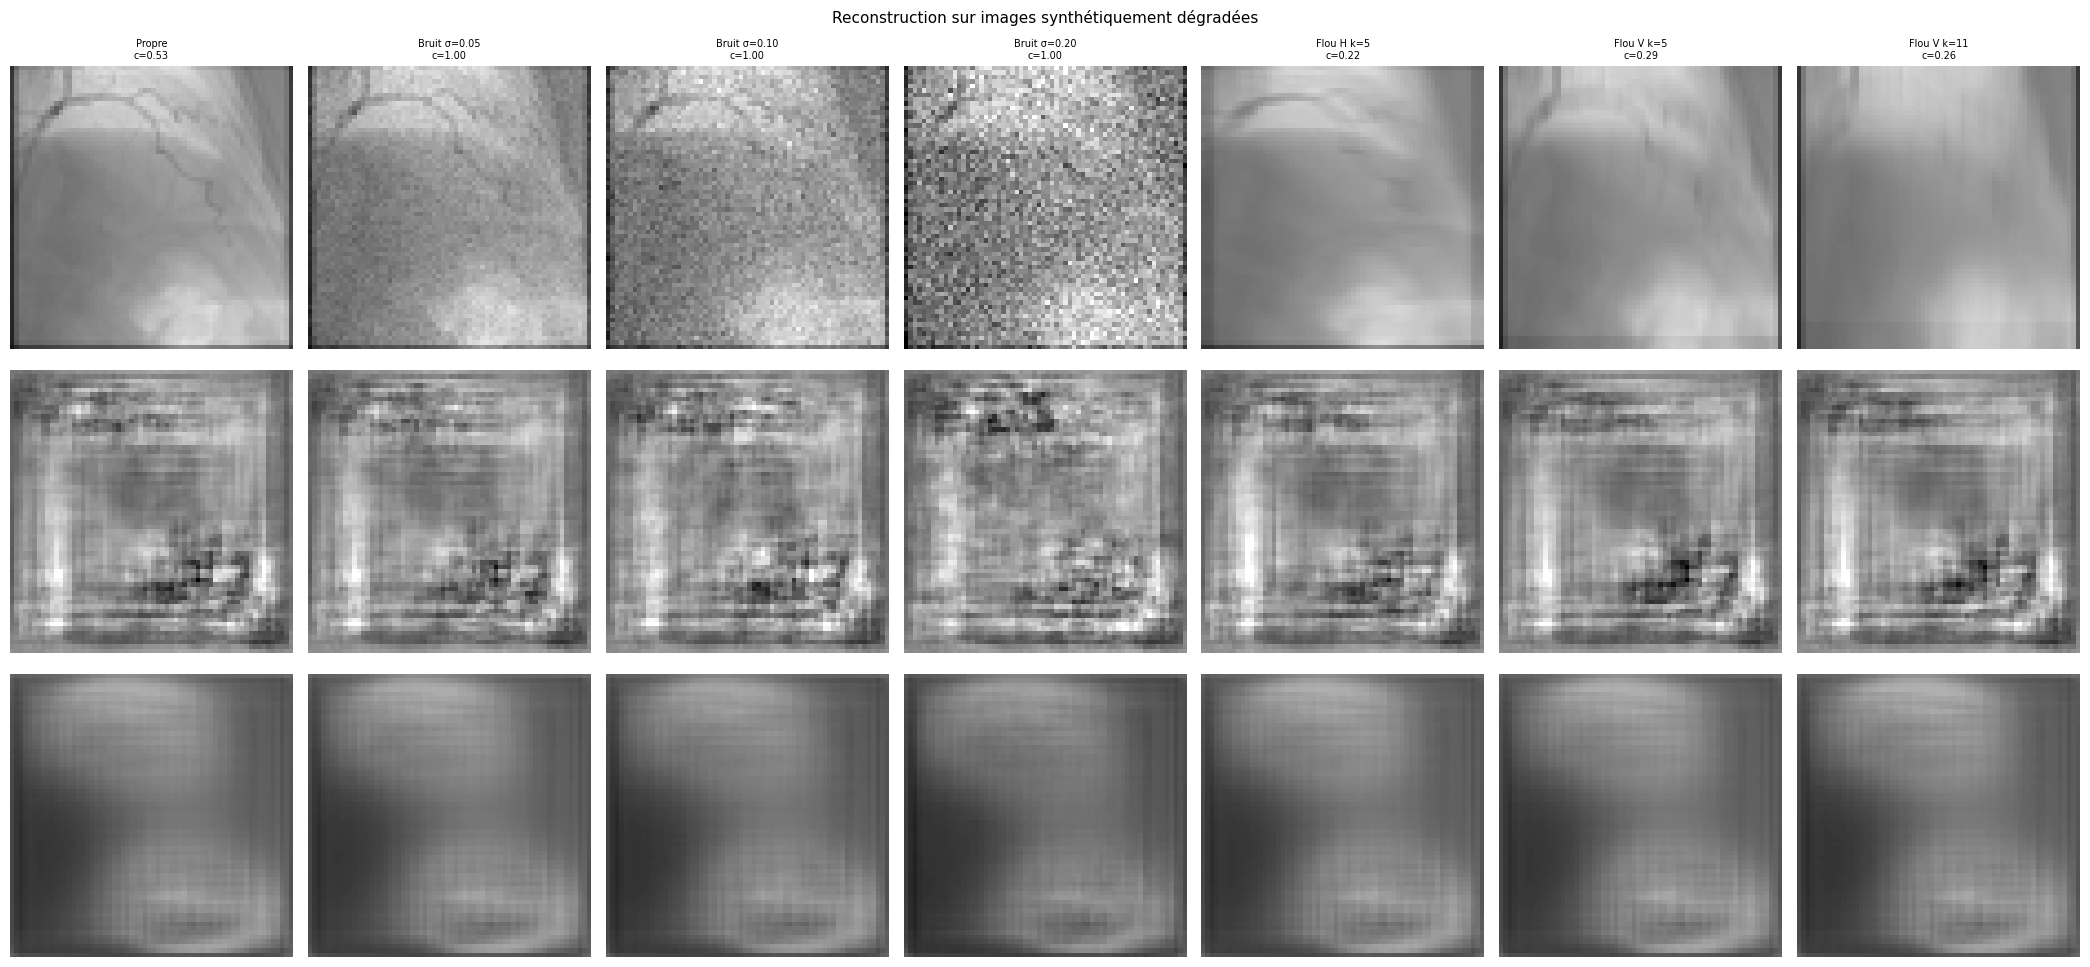

In [31]:
# Galerie sur les images dégradées synthétiquement (benchmark contrôlé)
if len(test_sets.get("good", pd.DataFrame())) > 0:
    x_gt = load_tensor(test_sets["good"]["path"].iloc[0]).to(DEVICE)

    fig, axes = plt.subplots(3, len(DEGRADATION_GRID), figsize=(3 * len(DEGRADATION_GRID), 10))
    row_labels = ["Dégradée (entrée)", "Baseline", "cVAE (ours)"]

    for col, d in enumerate(DEGRADATION_GRID):
        x_deg = d["fn"](x_gt)
        c_deg = torch.tensor([inline_quality_score(x_deg)], device=DEVICE)

        with torch.no_grad():
            rec_b, _, _ = baseline(x_deg, sample_posterior=False, decode=True)
            rec_c, _    = cvae(x_deg, c_deg, sample_posterior=False)

        for row_idx, (arr, cmap) in enumerate([
            (to_uint8(x_deg), "gray"),
            (to_uint8(rec_b),  "gray"),
            (to_uint8(rec_c),  "gray"),
        ]):
            axes[row_idx, col].imshow(arr, cmap=cmap, vmin=0, vmax=255)
            axes[row_idx, col].axis("off")
            if col == 0:
                axes[row_idx, col].set_ylabel(row_labels[row_idx], fontsize=8)
        axes[0, col].set_title(d["name"] + f"\nc={float(c_deg):.2f}", fontsize=7)

    fig.suptitle("Reconstruction sur images synthétiquement dégradées", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_gallery_synthetic.png", dpi=120, bbox_inches="tight")
    plt.show()

## 11. Tableau récapitulatif

In [32]:
print("=" * 75)
print(f"{'TABLEAU RÉCAPITULATIF':^75}")
print("=" * 75)

for metric, better in [("mse", "↓"), ("ssim", "↑"), ("psnr", "↑")]:
    print(f"\n  {metric.upper()} {better}")
    print(f"  {'Label':8s}  {'Baseline':>12s}  {'cVAE':>12s}  {'Δ (cvae−base)':>15s}  {'Amélioration':>14s}")
    print("  " + "-" * 65)
    for label in ["bad", "medium", "good", "ALL"]:
        if label == "ALL":
            sub = df_results
        else:
            sub = df_results[df_results["quality_label"] == label]
        if len(sub) == 0:
            continue
        mb = sub[f"base_{metric}"].mean()
        mc = sub[f"cvae_{metric}"].mean()
        d  = mc - mb
        # Pour MSE : amélioration si Δ < 0 ; pour SSIM/PSNR : si Δ > 0
        improved = (d < 0) if metric == "mse" else (d > 0)
        marker = "✓" if improved else "✗"
        pct = abs(d) / (abs(mb) + 1e-12) * 100
        print(f"  {label:8s}  {mb:12.5f}  {mc:12.5f}  {d:+15.5f}  {marker} {pct:+.1f}%")

print("\n" + "=" * 75)

                           TABLEAU RÉCAPITULATIF                           

  MSE ↓
  Label         Baseline          cVAE    Δ (cvae−base)    Amélioration
  -----------------------------------------------------------------
  bad            0.27822       0.04311         -0.23511  ✓ +84.5%
  medium         0.24432       0.06805         -0.17627  ✓ +72.1%
  good           0.21851       0.11529         -0.10322  ✓ +47.2%
  ALL            0.24702       0.07548         -0.17153  ✓ +69.4%

  SSIM ↑
  Label         Baseline          cVAE    Δ (cvae−base)    Amélioration
  -----------------------------------------------------------------
  bad            0.12940       0.52096         +0.39156  ✓ +302.6%
  medium         0.15014       0.53322         +0.38308  ✓ +255.2%
  good           0.16126       0.43755         +0.27630  ✓ +171.3%
  ALL            0.14693       0.49725         +0.35031  ✓ +238.4%

  PSNR ↑
  Label         Baseline          cVAE    Δ (cvae−base)    Amélioration
  ---------

## 12. Export des résultats

In [33]:
# Résultats images réelles
df_results.to_csv(OUTPUT_DIR / "05_evaluation_results.csv", index=False)
print(f"Sauvegardé → {OUTPUT_DIR / '05_evaluation_results.csv'}")

# Résultats dégradations synthétiques
if len(df_synth) > 0:
    df_synth.to_csv(OUTPUT_DIR / "05_synthetic_results.csv", index=False)
    print(f"Sauvegardé → {OUTPUT_DIR / '05_synthetic_results.csv'}")

Sauvegardé → C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_med_vae\code_tests\outputs\05_evaluation_results.csv
Sauvegardé → C:\Users\theop\Documents\Telecom_Paris\2A\cours\p4\IMA\IM_06\projet_med_vae\code_tests\outputs\05_synthetic_results.csv


## Résumé du Notebook 5

| Expérience | Description | Figure |
|---|---|---|
| Grille de dégradations | 7 types de dégradations synthétiques | `05_degradation_grid.png` |
| Métriques réelles | MSE/SSIM/PSNR par classe bad/medium/good | `05_boxplots.png` |
| Benchmark synthétique | MSE vs ground truth propre | `05_synthetic_metrics.png` |
| Test de Wilcoxon | Significativité statistique sur les images bad | Console |
| Galerie bad | Original \| Baseline \| cVAE \| Diff | `05_gallery_bad.png` |
| Galerie synthétique | Entrée dégradée \| Baseline \| cVAE | `05_gallery_synthetic.png` |

---

### Lecture des résultats

**Après entraînement complet (50 000+ steps)**, les résultats attendus sont :
- Sur les images `bad` : MSE du cVAE < MSE du baseline (le modèle ne s'effondre plus sur les artéfacts)
- Sur les images `good` : MSE du cVAE ≈ MSE du baseline (le conditionnement n'a pas dégradé les cas faciles)
- En dégradations synthétiques : la courbe cVAE doit rester plate (robuste) là où la courbe baseline monte

**Avec 50 steps de démonstration (NB4)**, les deux modèles sont quasi-identiques — c'est attendu et normal.

---

### Pipeline complet du projet

```
NB1 → MSCN + métriques brutes
NB2 → Cartes de qualité par patch (8 métriques × G×G)
NB3 → Score unique c ∈ [0,1]  →  labels_quality.csv
NB4 → QualityAwareAutoencoderKL  →  quality_aware_vae.pt
NB5 → Évaluation robustesse (ce notebook)
```